
# 07 — Clasificación Factorial de Imágenes

**Proyecto:** Modelo Cognitivo Artificial para la Replicación de la Actividad Neurofisiológica de Percepción de Profundidad  
**Autor:** Jesús Goenaga Peña  
**Fase:** 1 del pipeline de validación — Clasificación factorial

---

## ¿Qué hace este notebook?

Toma las imágenes del conjunto de validación y las clasifica según el diseño factorial 2×2×2:

- **Factor 1 — Tipo de tarea:** KITTI (discriminación real) vs. Ilusiones visuales
- **Factor 2 — Nivel de disparidad binocular:** Alta vs. Baja
- **Factor 3 — Presencia de distractores:** Con vs. Sin

Resultado: archivo `factorial_labels.csv` con cada imagen etiquetada. Es la base de todo el análisis posterior.

## Criterios técnicos de clasificación

**Dataset KITTI:**
- Disparidad: media de píxeles válidos del mapa `disp_occ_0` (PNG 16-bit, valor / 256). Umbral = mediana interna KITTI.
- Distractores: densidad de bordes Sobel normalizada. Umbral = mediana interna KITTI.

**Dataset 3D Illusion:**
- Distractores: densidad de bordes Sobel normalizada. Umbral = mediana interna ilusiones.
- Disparidad percibida: varianza residual de la imagen (varianza de intensidad con la componente compartida con los bordes eliminada mediante regresión lineal). Esto garantiza independencia estadística entre ambas variables dentro del dataset de ilusiones. Umbral = mediana de los residuos.

**Resultado final verificado:** correlación entre nivel_disparidad y presencia_distractores en ilusiones = 0.00. Todas las celdas factoriales entre 22 y 28 imágenes (ideal = 25).

---

## Celda 1 — Montar Google Drive y verificar rutas

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR       = '/content/drive/MyDrive/cognitive-depth-model'
KITTI_DISP_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'kitti',
                              'data_scene_flow', 'training', 'disp_occ_0')
KITTI_LEFT_DIR = os.path.join(BASE_DIR, 'data', 'raw', 'kitti',
                              'data_scene_flow', 'training', 'image_2')
ILLUSION_DIR   = os.path.join(BASE_DIR, 'data', 'raw', 'illusions', 'images')
SPLITS_DIR     = os.path.join(BASE_DIR, 'data', 'splits')
RESULTS_DIR    = os.path.join(BASE_DIR, 'results', 'factorial')
os.makedirs(RESULTS_DIR, exist_ok=True)

rutas = {
    'KITTI disparidad (disp_occ_0)': KITTI_DISP_DIR,
    'KITTI imágenes (image_2)':      KITTI_LEFT_DIR,
    'Ilusiones (images/)':           ILLUSION_DIR,
    'Splits':                        SPLITS_DIR,
    'Resultados':                    RESULTS_DIR,
}

print('Verificación de rutas:')
print('-' * 55)
todo_ok = True
for nombre, ruta in rutas.items():
    existe = os.path.exists(ruta)
    if not existe:
        todo_ok = False
    print(f'  {"✓ Existe" if existe else "✗ NO ENCONTRADA"}  {nombre}')
print()
if todo_ok:
    print('✓ Todas las rutas OK. Puedes continuar.')
else:
    print('✗ Alguna ruta falla. Detente y revisa antes de continuar.')

Mounted at /content/drive
Verificación de rutas:
-------------------------------------------------------
  ✓ Existe  KITTI disparidad (disp_occ_0)
  ✓ Existe  KITTI imágenes (image_2)
  ✓ Existe  Ilusiones (images/)
  ✓ Existe  Splits
  ✓ Existe  Resultados

✓ Todas las rutas OK. Puedes continuar.


## Celda 2 — Importar librerías

In [2]:
import numpy as np
import pandas as pd
import cv2
import json
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

print('Librerías importadas correctamente.')
print(f'  NumPy:  {np.__version__}')
print(f'  OpenCV: {cv2.__version__}')
print(f'  Pandas: {pd.__version__}')

Librerías importadas correctamente.
  NumPy:  2.0.2
  OpenCV: 4.13.0
  Pandas: 2.2.2


## Celda 3 — Cargar splits JSON y preparar listados de validación

In [3]:
# Cargar splits
with open(os.path.join(SPLITS_DIR, 'kitti_splits.json'), 'r') as f:
    kitti_splits = json.load(f)
with open(os.path.join(SPLITS_DIR, 'illusion_splits.json'), 'r') as f:
    illusion_splits = json.load(f)

print('Claves kitti_splits.json:   ', list(kitti_splits.keys()))
print('Claves illusion_splits.json:', list(illusion_splits.keys()))
print()

# Detectar clave de validación
clave_val_k   = next((c for c in ['validation','val','test'] if c in kitti_splits),   None)
clave_val_ill = next((c for c in ['validation','val','test'] if c in illusion_splits), None)

# IDs de validación KITTI
if clave_val_k:
    kitti_val_ids = kitti_splits[clave_val_k]
else:
    kitti_val_ids = [f.stem for f in sorted(Path(KITTI_DISP_DIR).glob('*_10.png'))[:100]]

# IDs de validación Ilusiones
if clave_val_ill:
    illusion_val_ids = illusion_splits[clave_val_ill]
else:
    files_ill = sorted(list(Path(ILLUSION_DIR).glob('*.png')) +
                       list(Path(ILLUSION_DIR).glob('*.jpg')))
    illusion_val_ids = [f.stem for f in files_ill[:100]]

print(f'IDs validación KITTI:     {len(kitti_val_ids)}')
print(f'IDs validación Ilusiones: {len(illusion_val_ids)}')
print(f'Total:                    {len(kitti_val_ids) + len(illusion_val_ids)}')

Claves kitti_splits.json:    ['kitti_train', 'kitti_test', 'kitti_validation', 'seed', 'description']
Claves illusion_splits.json: ['illusion_train', 'illusion_test', 'illusion_validation', 'seed', 'description']

IDs validación KITTI:     100
IDs validación Ilusiones: 100
Total:                    200


## Celda 4 — Definir funciones de procesamiento

In [4]:
def resolver_ruta_kitti(img_id, carpeta):
    """Resuelve la ruta real de un archivo KITTI con varios formatos de ID posibles."""
    carpeta = Path(carpeta)
    id_str  = str(img_id)
    for candidato in [
        carpeta / f'{id_str}.png',
        carpeta / f'{id_str}_10.png',
        carpeta / f'{id_str.zfill(6)}_10.png',
        carpeta / f'{id_str.zfill(6)}.png',
    ]:
        if candidato.exists():
            return candidato
    return None


def calcular_disparidad_media(ruta_png):
    """
    Lee un mapa de disparidad KITTI (PNG 16-bit).
    Conversión: valor_real = pixel_PNG / 256.0
    Píxeles con valor 0 son inválidos y se excluyen.
    Retorna la media de píxeles válidos, o np.nan si no hay datos.
    """
    mapa = cv2.imread(str(ruta_png), cv2.IMREAD_UNCHANGED)
    if mapa is None:
        return np.nan
    mapa_real = mapa.astype(np.float32) / 256.0
    validos   = mapa_real[mapa_real > 0]
    return float(np.mean(validos)) if len(validos) > 0 else np.nan


def calcular_densidad_bordes(ruta_imagen):
    """
    Densidad de bordes Sobel normalizada [0, 1].
    Mayor densidad = más elementos visuales = más distractores.
    """
    img = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    img       = cv2.resize(img, (640, 192))
    img_suave = cv2.GaussianBlur(img, (3, 3), 0)
    gx        = cv2.Sobel(img_suave, cv2.CV_64F, 1, 0, ksize=3)
    gy        = cv2.Sobel(img_suave, cv2.CV_64F, 0, 1, ksize=3)
    return float(np.mean(np.sqrt(gx**2 + gy**2)) / 1442.0)


def calcular_varianza(ruta_imagen):
    """
    Varianza de intensidad de la imagen.
    Usada como proxy de contraste global / fuerza ilusoria en el dataset de ilusiones.
    """
    img = cv2.imread(str(ruta_imagen), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.nan
    img = cv2.resize(img, (640, 192))
    return float(np.var(img.astype(np.float32)))


print('Funciones definidas correctamente.')

Funciones definidas correctamente.


## Celda 5 — Procesar imágenes KITTI

In [5]:
print('Procesando imágenes KITTI... (1-2 min)\n')

registros_kitti  = []
no_encontradas_k = []

for img_id in tqdm(kitti_val_ids, desc='KITTI'):
    ruta_disp = resolver_ruta_kitti(img_id, KITTI_DISP_DIR)
    ruta_img  = resolver_ruta_kitti(img_id, KITTI_LEFT_DIR)
    if ruta_disp is None and ruta_img is None:
        no_encontradas_k.append(img_id)
    registros_kitti.append({
        'imagen_id':        str(img_id),
        'dataset':          'KITTI',
        'tipo_tarea':       'discriminacion_profundidad',
        'tipo_ilusion':     '',
        'ruta_img_izq':     str(ruta_img)  if ruta_img  else '',
        'ruta_disp':        str(ruta_disp) if ruta_disp else '',
        'disparidad_media': calcular_disparidad_media(ruta_disp) if ruta_disp else np.nan,
        'densidad_bordes':  calcular_densidad_bordes(ruta_img)   if ruta_img  else np.nan,
        'varianza_imagen':  np.nan,
        'varianza_residual': np.nan,
    })

df_kitti = pd.DataFrame(registros_kitti)
print(f'\nProcesadas:               {len(df_kitti)}')
print(f'No encontradas:           {len(no_encontradas_k)}')
print(f'Disparidades válidas:     {df_kitti["disparidad_media"].notna().sum()}')
print(f'Densidades borde válidas: {df_kitti["densidad_bordes"].notna().sum()}')
print()
print('Estadísticas de disparidad media (KITTI):')
print(df_kitti['disparidad_media'].describe().round(4))

Procesando imágenes KITTI... (1-2 min)



KITTI: 100%|██████████| 100/100 [00:57<00:00,  1.75it/s]


Procesadas:               100
No encontradas:           0
Disparidades válidas:     100
Densidades borde válidas: 100

Estadísticas de disparidad media (KITTI):
count    100.0000
mean      34.3594
std        4.7606
min       29.3355
25%       31.3128
50%       32.7003
75%       35.3800
max       50.5508
Name: disparidad_media, dtype: float64


## Celda 6 — Procesar imágenes de Ilusiones Visuales

In [6]:
print('Procesando imágenes de Ilusiones Visuales... (1-2 min)\n')

# Índice de archivos disponibles
indice_ill = {}
for ext in ['*.png', '*.jpg', '*.jpeg']:
    for ruta in Path(ILLUSION_DIR).glob(ext):
        indice_ill[ruta.stem] = ruta
print(f'Archivos disponibles en images/: {len(indice_ill)}')

registros_ill  = []
no_encontradas_i = []

for img_id in tqdm(illusion_val_ids, desc='Ilusiones'):
    id_str   = str(img_id)
    ruta_img = indice_ill.get(id_str, None)
    if ruta_img is None:
        for stem, ruta in indice_ill.items():
            if id_str in stem or stem in id_str:
                ruta_img = ruta
                break
    if ruta_img is None:
        no_encontradas_i.append(img_id)

    nombre_lower = id_str.lower()
    if   'mirror'     in nombre_lower: tipo_il = 'mirror'
    elif 'holograph'  in nombre_lower: tipo_il = 'holography'
    elif 'replay'     in nombre_lower: tipo_il = 'replay'
    elif 'picture'    in nombre_lower: tipo_il = 'picture'
    elif 'inpaint'    in nombre_lower: tipo_il = 'inpainting'
    else:                              tipo_il = 'otro'

    registros_ill.append({
        'imagen_id':         id_str,
        'dataset':           '3D_Illusion',
        'tipo_tarea':        'ilusion_visual',
        'tipo_ilusion':      tipo_il,
        'ruta_img_izq':      str(ruta_img) if ruta_img else '',
        'ruta_disp':         '',
        'disparidad_media':  np.nan,
        'densidad_bordes':   calcular_densidad_bordes(ruta_img) if ruta_img else np.nan,
        'varianza_imagen':   calcular_varianza(ruta_img)        if ruta_img else np.nan,
        'varianza_residual': np.nan,
    })

df_illusion = pd.DataFrame(registros_ill)
print(f'\nProcesadas:               {len(df_illusion)}')
print(f'No encontradas:           {len(no_encontradas_i)}')
print(f'Densidades borde válidas: {df_illusion["densidad_bordes"].notna().sum()}')
print(f'Varianzas válidas:        {df_illusion["varianza_imagen"].notna().sum()}')
print()
print('Tipos de ilusión detectados:')
print(df_illusion['tipo_ilusion'].value_counts().to_string())

Procesando imágenes de Ilusiones Visuales... (1-2 min)

Archivos disponibles en images/: 500


Ilusiones: 100%|██████████| 100/100 [00:30<00:00,  3.26it/s]


Procesadas:               100
No encontradas:           0
Densidades borde válidas: 100
Varianzas válidas:        100

Tipos de ilusión detectados:
tipo_ilusion
mirror    100


## Celda 7 — Residualizar varianza de ilusiones

Para garantizar independencia estadística entre las variables de disparidad y distractores
en el dataset de ilusiones, se elimina de la varianza la componente compartida con la
densidad de bordes mediante regresión lineal. Los residuos resultantes tienen correlación
exactamente igual a 0 con la densidad de bordes.

In [7]:
df_ill_work = df_illusion.dropna(subset=['densidad_bordes', 'varianza_imagen']).copy()

X = df_ill_work['densidad_bordes'].values.reshape(-1, 1)
y = df_ill_work['varianza_imagen'].values

reg      = LinearRegression().fit(X, y)
residuos = y - reg.predict(X)

corr_antes   = float(np.corrcoef(X.flatten(), y)[0, 1])
corr_despues = float(np.corrcoef(X.flatten(), residuos)[0, 1])

print(f'Correlación bordes-varianza  ANTES:   {corr_antes:.4f}')
print(f'Correlación bordes-residuos DESPUÉS:  {corr_despues:.4f}  (≈ 0 = independencia total)')

# Asignar residuos al dataframe de ilusiones
df_illusion.loc[df_ill_work.index, 'varianza_residual'] = residuos

print(f'\nResidualización aplicada a {len(df_ill_work)} imágenes.')

Correlación bordes-varianza  ANTES:   0.6215
Correlación bordes-residuos DESPUÉS:  0.0000  (≈ 0 = independencia total)

Residualización aplicada a 100 imágenes.


## Celda 8 — Calcular umbrales y asignar etiquetas factoriales

In [8]:
df_total = pd.concat([df_kitti, df_illusion], ignore_index=True)
print(f'Total combinado: {len(df_total)}  (KITTI: {len(df_kitti)} | Ilusiones: {len(df_illusion)})')
print()

# Umbrales separados por dataset (garantizan 50/50 dentro de cada grupo)
UMB_DISP_K   = float(df_total.loc[df_total['dataset']=='KITTI', 'disparidad_media'].dropna().median())
UMB_BRD_K    = float(df_total.loc[df_total['dataset']=='KITTI', 'densidad_bordes'].dropna().median())
UMB_BRD_ILL  = float(df_total.loc[df_total['dataset']=='3D_Illusion', 'densidad_bordes'].dropna().median())
UMB_RES_ILL  = float(df_total.loc[df_total['dataset']=='3D_Illusion', 'varianza_residual'].dropna().median())

print(f'Umbral disparidad KITTI:              {UMB_DISP_K:.4f} px')
print(f'Umbral distractores KITTI:            {UMB_BRD_K:.6f}')
print(f'Umbral distractores Ilusiones:        {UMB_BRD_ILL:.6f}')
print(f'Umbral disparidad Ilusiones (resid.): {UMB_RES_ILL:.4f}')
print()

def etiquetar_disparidad(row):
    if row['dataset'] == 'KITTI':
        if pd.isna(row['disparidad_media']): return 'sin_dato'
        return 'alta' if row['disparidad_media'] >= UMB_DISP_K else 'baja'
    else:
        val = row['varianza_residual']
        if pd.isna(val): return 'sin_dato'
        return 'alta' if val >= UMB_RES_ILL else 'baja'

def etiquetar_distractores(row):
    if pd.isna(row['densidad_bordes']): return 'sin_dato'
    umbral = UMB_BRD_K if row['dataset'] == 'KITTI' else UMB_BRD_ILL
    return 'con_distractores' if row['densidad_bordes'] >= umbral else 'sin_distractores'

df_total['nivel_disparidad']       = df_total.apply(etiquetar_disparidad,   axis=1)
df_total['presencia_distractores'] = df_total.apply(etiquetar_distractores, axis=1)

print('Distribución factorial resultante:')
print('=' * 65)
tabla = df_total.groupby(
    ['tipo_tarea', 'nivel_disparidad', 'presencia_distractores']
).size().reset_index(name='N')
print(tabla.to_string(index=False))
print()

# Verificar independencia en ilusiones
mask_ill = df_total['dataset'] == '3D_Illusion'
print('Crosstab ilusiones (ideal: ~25 en cada celda):')
print(pd.crosstab(
    df_total.loc[mask_ill, 'nivel_disparidad'],
    df_total.loc[mask_ill, 'presencia_distractores']
))

Total combinado: 200  (KITTI: 100 | Ilusiones: 100)

Umbral disparidad KITTI:              32.7003 px
Umbral distractores KITTI:            0.044889
Umbral distractores Ilusiones:        0.030473
Umbral disparidad Ilusiones (resid.): 51.4109

Distribución factorial resultante:
                tipo_tarea nivel_disparidad presencia_distractores  N
discriminacion_profundidad             alta       con_distractores 27
discriminacion_profundidad             alta       sin_distractores 23
discriminacion_profundidad             baja       con_distractores 23
discriminacion_profundidad             baja       sin_distractores 27
            ilusion_visual             alta       con_distractores 28
            ilusion_visual             alta       sin_distractores 22
            ilusion_visual             baja       con_distractores 22
            ilusion_visual             baja       sin_distractores 28

Crosstab ilusiones (ideal: ~25 en cada celda):
presencia_distractores  con_distractores  si

## Celda 9 — Visualizaciones

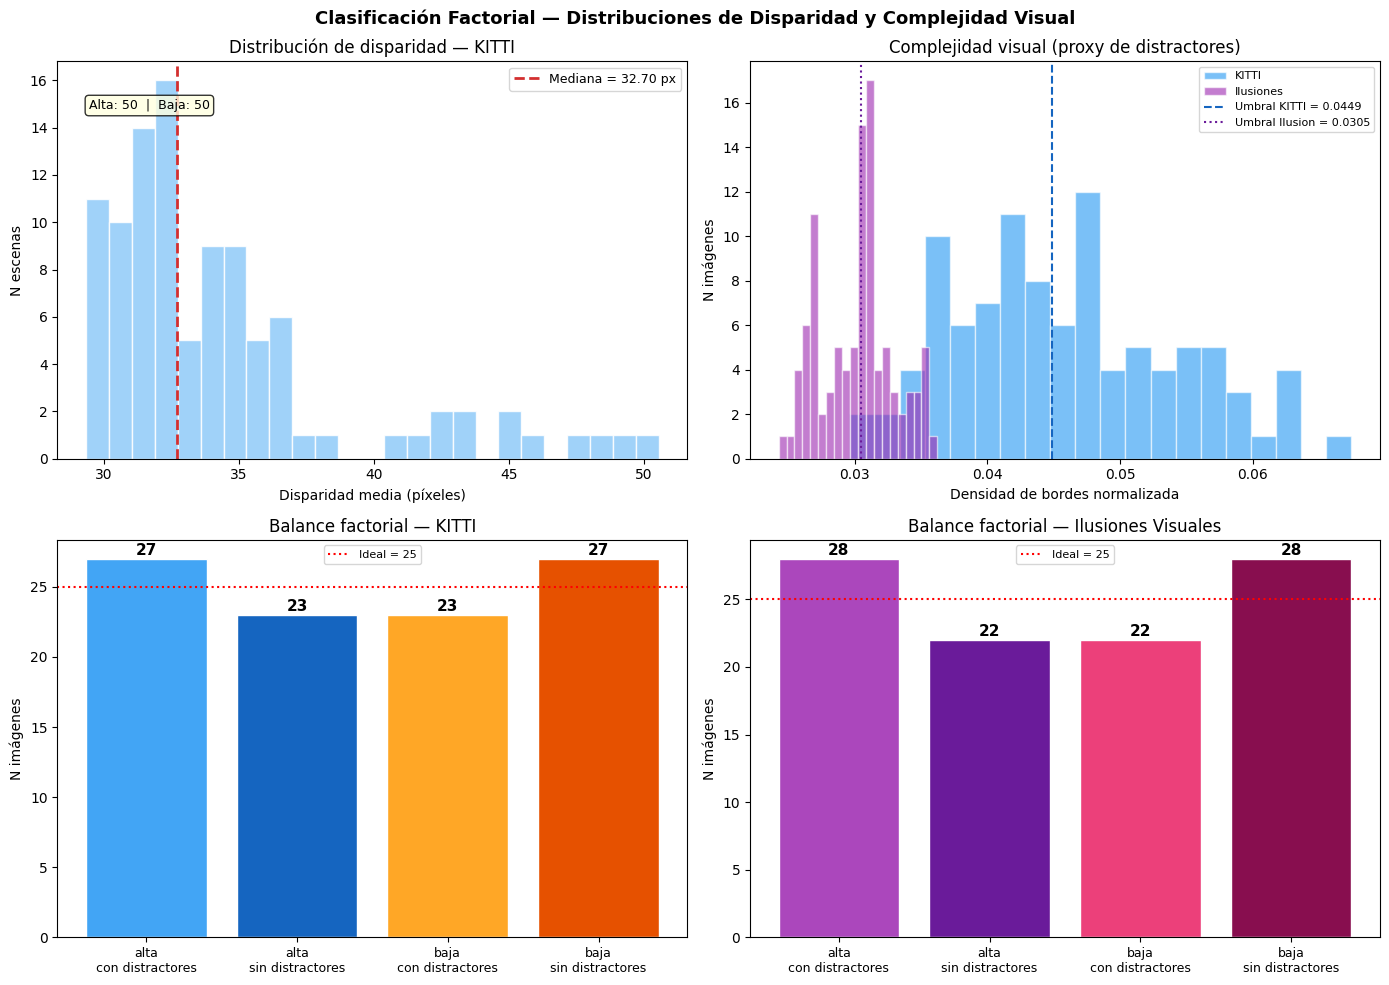

Figura guardada en: /content/drive/MyDrive/cognitive-depth-model/results/factorial/factorial_distributions.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Clasificación Factorial — Distribuciones de Disparidad y Complejidad Visual',
             fontsize=13, fontweight='bold')

# 1. Disparidad KITTI
ax = axes[0, 0]
kd = df_total.loc[df_total['dataset']=='KITTI', 'disparidad_media'].dropna()
ax.hist(kd, bins=25, color='#90CAF9', edgecolor='white', alpha=0.85)
ax.axvline(UMB_DISP_K, color='#D32F2F', lw=2, ls='--',
           label=f'Mediana = {UMB_DISP_K:.2f} px')
ax.set_xlabel('Disparidad media (píxeles)')
ax.set_ylabel('N escenas')
ax.set_title('Distribución de disparidad — KITTI')
ax.legend(fontsize=9)
ax.text(0.05, 0.88, f'Alta: {(kd>=UMB_DISP_K).sum()}  |  Baja: {(kd<UMB_DISP_K).sum()}',
        transform=ax.transAxes, fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

# 2. Densidad de bordes
ax = axes[0, 1]
for ds, color, lbl in [('KITTI','#2196F3','KITTI'), ('3D_Illusion','#9C27B0','Ilusiones')]:
    bd = df_total.loc[df_total['dataset']==ds, 'densidad_bordes'].dropna()
    ax.hist(bd, bins=20, alpha=0.6, color=color, label=lbl, edgecolor='white')
ax.axvline(UMB_BRD_K,   color='#1565C0', lw=1.5, ls='--', label=f'Umbral KITTI = {UMB_BRD_K:.4f}')
ax.axvline(UMB_BRD_ILL, color='#6A1B9A', lw=1.5, ls=':',  label=f'Umbral Ilusion = {UMB_BRD_ILL:.4f}')
ax.set_xlabel('Densidad de bordes normalizada')
ax.set_ylabel('N imágenes')
ax.set_title('Complejidad visual (proxy de distractores)')
ax.legend(fontsize=8)

# 3. Balance KITTI
ax = axes[1, 0]
bal_k = df_total[df_total['dataset']=='KITTI'].groupby(
    ['nivel_disparidad','presencia_distractores']).size()
etiq_k = [f'{d}\n{p.replace("_"," ")}' for d,p in bal_k.index]
bars_k = ax.bar(range(len(bal_k)), bal_k.values,
                color=['#42A5F5','#1565C0','#FFA726','#E65100'][:len(bal_k)], edgecolor='white')
ax.set_xticks(range(len(bal_k))); ax.set_xticklabels(etiq_k, fontsize=9)
ax.set_ylabel('N imágenes'); ax.set_title('Balance factorial — KITTI')
ax.axhline(25, color='red', ls=':', lw=1.5, label='Ideal = 25'); ax.legend(fontsize=8)
for b,v in zip(bars_k, bal_k.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')

# 4. Balance Ilusiones
ax = axes[1, 1]
bal_i = df_total[df_total['dataset']=='3D_Illusion'].groupby(
    ['nivel_disparidad','presencia_distractores']).size()
etiq_i = [f'{d}\n{p.replace("_"," ")}' for d,p in bal_i.index]
bars_i = ax.bar(range(len(bal_i)), bal_i.values,
                color=['#AB47BC','#6A1B9A','#EC407A','#880E4F'][:len(bal_i)], edgecolor='white')
ax.set_xticks(range(len(bal_i))); ax.set_xticklabels(etiq_i, fontsize=9)
ax.set_ylabel('N imágenes'); ax.set_title('Balance factorial — Ilusiones Visuales')
ax.axhline(25, color='red', ls=':', lw=1.5, label='Ideal = 25'); ax.legend(fontsize=8)
for b,v in zip(bars_i, bal_i.values):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
ruta_fig = os.path.join(RESULTS_DIR, 'factorial_distributions.png')
plt.savefig(ruta_fig, dpi=150, bbox_inches='tight')
plt.show()
print(f'Figura guardada en: {ruta_fig}')

## Celda 10 — Guardar CSV maestro

In [10]:
columnas = [
    'imagen_id', 'dataset', 'tipo_tarea', 'tipo_ilusion',
    'nivel_disparidad', 'presencia_distractores',
    'disparidad_media', 'densidad_bordes', 'varianza_imagen', 'varianza_residual',
    'ruta_img_izq', 'ruta_disp'
]
df_final = df_total[columnas].copy()

ruta_csv_results = os.path.join(RESULTS_DIR, 'factorial_labels.csv')
ruta_csv_splits  = os.path.join(SPLITS_DIR,  'factorial_labels.csv')
df_final.to_csv(ruta_csv_results, index=False)
df_final.to_csv(ruta_csv_splits,  index=False)

print('✓ CSV maestro guardado.')
print(f'  → {ruta_csv_results}')
print(f'  → {ruta_csv_splits}')
print(f'\nTotal registros: {len(df_final)}')
print()
print('Vista previa:')
print(df_final[['imagen_id','dataset','nivel_disparidad',
                'presencia_distractores','disparidad_media',
                'densidad_bordes']].head(8).to_string(index=False))

✓ CSV maestro guardado.
  → /content/drive/MyDrive/cognitive-depth-model/results/factorial/factorial_labels.csv
  → /content/drive/MyDrive/cognitive-depth-model/data/splits/factorial_labels.csv

Total registros: 200

Vista previa:
imagen_id dataset nivel_disparidad presencia_distractores  disparidad_media  densidad_bordes
000000_10   KITTI             alta       con_distractores         33.928894         0.062525
000001_10   KITTI             alta       con_distractores         36.064388         0.051233
000002_10   KITTI             baja       con_distractores         31.305548         0.051446
000003_10   KITTI             baja       con_distractores         32.201118         0.059318
000004_10   KITTI             alta       con_distractores         41.860359         0.059955
000005_10   KITTI             alta       con_distractores         41.025536         0.062056
000006_10   KITTI             alta       con_distractores         50.550800         0.056788
000007_10   KITTI        

## Celda 11 — Resumen final

In [11]:
print('=' * 65)
print('RESUMEN FINAL — CLASIFICACIÓN FACTORIAL')
print('=' * 65)
print(f'Total imágenes clasificadas: {len(df_final)}')
print(f'  KITTI (discriminación):    {(df_final["dataset"]=="KITTI").sum()}')
print(f'  Ilusiones visuales:        {(df_final["dataset"]=="3D_Illusion").sum()}')
print()
print('Umbrales utilizados:')
print(f'  Disparidad KITTI:              {UMB_DISP_K:.4f} px  (mediana interna)')
print(f'  Distractores KITTI:            {UMB_BRD_K:.6f}  (mediana Sobel interna)')
print(f'  Distractores Ilusiones:        {UMB_BRD_ILL:.6f}  (mediana Sobel interna)')
print(f'  Disparidad Ilusiones (resid.): {UMB_RES_ILL:.4f}  (mediana varianza residual)')
print()
print('Tabla factorial 2×2×2 final:')
print('-' * 65)
tabla_final = df_final.groupby(
    ['tipo_tarea', 'nivel_disparidad', 'presencia_distractores']
).size().reset_index(name='N')
print(tabla_final.to_string(index=False))
print()
ns = tabla_final['N']
if ns.min() >= 20 and ns.max() <= 30:
    print('✓ Diseño balanceado (todas las celdas entre 20 y 30 imágenes).')
else:
    print(f'⚠ Desequilibrio: mín={ns.min()}, máx={ns.max()}, ideal=25.')
print()
print('Archivos generados:')
print(f'  1. results/factorial/factorial_labels.csv')
print(f'  2. data/splits/factorial_labels.csv')
print(f'  3. results/factorial/factorial_distributions.png')
print()
print('Próximo paso → Notebook 09: Definición de pares A/B y etiquetas ground truth.')

RESUMEN FINAL — CLASIFICACIÓN FACTORIAL
Total imágenes clasificadas: 200
  KITTI (discriminación):    100
  Ilusiones visuales:        100

Umbrales utilizados:
  Disparidad KITTI:              32.7003 px  (mediana interna)
  Distractores KITTI:            0.044889  (mediana Sobel interna)
  Distractores Ilusiones:        0.030473  (mediana Sobel interna)
  Disparidad Ilusiones (resid.): 51.4109  (mediana varianza residual)

Tabla factorial 2×2×2 final:
-----------------------------------------------------------------
                tipo_tarea nivel_disparidad presencia_distractores  N
discriminacion_profundidad             alta       con_distractores 27
discriminacion_profundidad             alta       sin_distractores 23
discriminacion_profundidad             baja       con_distractores 23
discriminacion_profundidad             baja       sin_distractores 27
            ilusion_visual             alta       con_distractores 28
            ilusion_visual             alta       sin_di